### Бибилиотеки и Данные

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

u = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6lab/use/user_info.csv', sep=';')
c = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6lab/use/chat.csv', sep=';')
con = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6lab/use/connection.csv', sep=';')
t = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6lab/use/student_test_result.csv', sep=';')
l = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6lab/use/lesson.csv', sep=';')

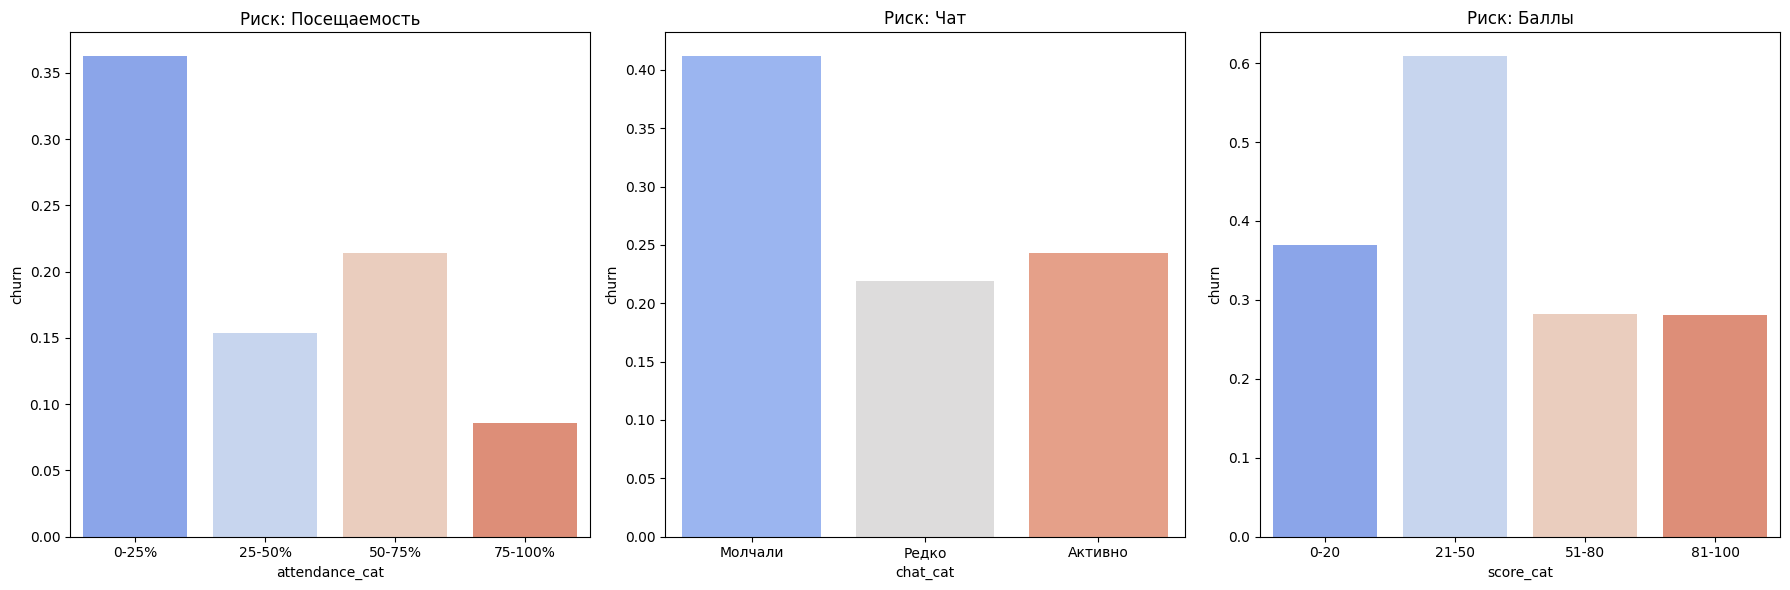

In [ ]:
# Посещаемость
total_lessons = l.groupby('education_group_id')['id'].nunique()
u['total_l'] = u['education_group_id'].map(total_lessons)

attended_lessons = con.groupby('user_id')['lesson_id'].nunique()
u['attended_l'] = u['user_id'].map(attended_lessons).fillna(0)

u['attendance_rate'] = u['attended_l'] / u['total_l']

# Чат
chat_sum = c.groupby('sender_id')['message_symbols'].sum()
u['total_chars'] = u['user_id'].map(chat_sum).fillna(0)
u['chat_intensity'] = u['total_chars'] / u['attended_l']
u['chat_intensity'] = u['chat_intensity'].fillna(0)

# Тесты
test_avg = t.groupby('student_id')['percent'].mean()
u['avg_score'] = u['user_id'].map(test_avg).fillna(0)

# Биннинг
u['attendance_cat'] = pd.cut(u['attendance_rate'], bins=[-0.1, 0.25, 0.5, 0.75, 1.0], labels=['0-25%', '25-50%', '50-75%', '75-100%'])
u['score_cat'] = pd.cut(u['avg_score'], bins=[-1, 20, 50, 80, 100], labels=['0-20', '21-50', '51-80', '81-100'])
u['chat_cat'] = pd.cut(u['chat_intensity'], bins=[-1, 0, 10, 1000], labels=['Молчали', 'Редко', 'Активно'])

# Визуал

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Посещаемость
sns.barplot(data=u, x='attendance_cat', y='churn', ax=axes[0], palette="coolwarm", hue='attendance_cat', legend=False, errorbar=None)
axes[0].set_title('Риск: Посещаемость')

# 2) Чат
sns.barplot(data=u, x='chat_cat', y='churn', ax=axes[1], palette="coolwarm", hue='chat_cat', legend=False, errorbar=None)
axes[1].set_title('Риск: Чат')

# 3) Тесты
sns.barplot(data=u, x='score_cat', y='churn', ax=axes[2], palette="coolwarm", hue='score_cat', legend=False, errorbar=None)
axes[2].set_title('Риск: Баллы')

plt.tight_layout()
plt.show()

In [ ]:
print("\nСредние значения по группам")
print(u.groupby('churn')[['attendance_rate', 'avg_score', 'chat_intensity']].mean())

print("\nПроцент и количество оттока по категориям")

for col in ['attendance_cat', 'score_cat', 'chat_cat']:
    print()

    # Группировка с count, mean и sum
    grouped = u.groupby(col)['churn'].agg(['count', 'mean', 'sum'])
    grouped['mean'] = grouped['mean'] * 100  # в проценты

    # Переименование колонок
    grouped.columns = ['всего', 'отток_%', 'отток_чел']

    # Сортировка по проценту оттока
    print(grouped.sort_values('отток_%', ascending=False))
    print(f"Всего студентов: {grouped['всего'].sum()}")


Средние значения по группам
       attendance_rate  avg_score  chat_intensity
churn                                            
False         0.229914  64.609377      155.826282
True          0.085459  58.176240       97.052358

Процент и количество оттока по категориям

                всего    отток_%  отток_чел
attendance_cat                             
0-25%             941  36.238045        341
50-75%             42  21.428571          9
25-50%            130  15.384615         20
75-100%            35   8.571429          3
Всего студентов: 1148

           всего    отток_%  отток_чел
score_cat                             
21-50         46  60.869565         28
0-20         249  36.947791         92
51-80        383  28.198433        108
81-100       533  28.142589        150
Всего студентов: 1211

          всего    отток_%  отток_чел
chat_cat                             
Молчали     515  41.165049        212
Активно     650  24.307692        158
Редко        32  21.875000     

/tmp/ipykernel_218/2255180620.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = u.groupby(col)['churn'].agg(['count', 'mean', 'sum'])
/tmp/ipykernel_218/2255180620.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = u.groupby(col)['churn'].agg(['count', 'mean', 'sum'])
/tmp/ipykernel_218/2255180620.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = u.groupby(col)['churn'].agg(['count',

### Общий вывод по графику:

1. **Прямая зависимость риска оттока от дисциплины:**
Мы видим четкую тенденцию: чем чаще ученик пропускает занятия, тем выше вероятность того, что он пропадет. Группа «0-25%» — это доля ушедших учеников максимальна. Это доказывает, что пропуски — не просто временная проблема, а предвестник полной потери мотивации.
2. **Эффект «социального якоря»:**
График активности в чате показывает, что даже простое общение на уроке работает как «защитный механизм». Ученики, которые задают вопросы или проявляют активность *(группа «Активно»)*, уходят значительно реже, чем те, кто сохраняет пассивность *(«Молчали»)*. Социальная вовлеченность привязывает ученика к группе и преподавателю.
3. **Академический успех как индикатор:**
График по баллам за тесты демонстрирует, что низкая успеваемость *(категория «0-20» и «21-50»)* коррелирует с чуть более высоким оттоком. Это подтверждает гипотезу о «фрустрации»: когда ученик не видит прогресса и получает низкие баллы, он подсознательно теряет интерес к курсу.

**Итоговый вывод для бизнеса:**
Самый опасный сегмент — это «тихие прогульщики» с низким средним баллом. Если отдел заботы будет отслеживать учеников, которые перестали посещать занятия и замолчали в чате, это позволит выявлять риск расторжения договора до того, как ученик официально подаст заявление на уход. Эти данные можно использовать для настройки автоматических триггеров *(например, персональных писем от кураторов при пропуске 2-х занятий подряд)*.